In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables
import pandas as pd

params = {'figure.figsize': (10, 10*0.618),
          'legend.fontsize': 14,
          'axes.labelsize': 16,
          'axes.titlesize': 16,
          'xtick.labelsize': 16,
          'ytick.labelsize': 16}
plt.rcParams.update(params)

In [2]:
df = pd.read_hdf('../../dataset_complete/BDT/BDT_all_updated.h5', key='data')

In [28]:
boolCC = (df.Label == 1) & (df.TrueEnergy >= 2) & (df.TrueEnergy <= 15) & (df.TrueZenith <= -0.3)
boolNC = (df.Label == 0) & (df.TrueEnergy >= 2) & (df.TrueEnergy <= 15) & (df.TrueZenith <= -0.3)

In [29]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 1#10
    else:
        max_val = 1 #30 #charge
    
    for i in np.arange(-1, max_val, 0.1):#range(0, len(charge_val)-1):#
        qmin= i #i*10 #charge_val[i]#
        qmax= i+0.1#(i+1)*10 #charge_val[i+1]#
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len( xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-(0.1/2)) #append(qmax - 5)

    return sep_var, p_val, bin_centers

In [30]:
sep_var_median_angle, p_val_median_angle, bin_centers_median_angle = get_statistic(df.ang_median[boolCC], df.ang_median[boolNC], df.TrueZenith[boolCC], df.TrueZenith[boolNC])
sep_var_iqr_angle, p_val_iqr_angle, bin_centers_iqr_angle = get_statistic(df.ang_iqr[boolCC], df.ang_iqr[boolNC], df.TrueZenith[boolCC], df.TrueZenith[boolNC])

csep_var_median_angle, cp_val_median_angle, cbin_centers_median_angle = get_statistic(df.TrueZenith[boolCC], df.ang_median[boolNC], df.RecoZenith[boolCC], df.RecoZenith[boolNC], energy=False)
csep_var_iqr_angle, cp_val_iqr_angle, cbin_centers_iqr_angle = get_statistic(df.ang_iqr[boolCC], df.ang_iqr[boolNC], df.RecoZenith[boolCC], df.RecoZenith[boolNC], energy=False)

In [31]:
sep_var_median_dist, p_val_median_dist, bin_centers_median_dist = get_statistic(df.dist_median[boolCC], df.dist_median[boolNC], df.TrueZenith[boolCC], df.TrueZenith[boolNC])
sep_var_iqr_dist, p_val_iqr_dist, bin_centers_iqr_dist = get_statistic(df.dist_iqr[boolCC], df.dist_iqr[boolNC], df.TrueZenith[boolCC], df.TrueZenith[boolNC])

csep_var_median_dist, cp_val_median_dist, cbin_centers_median_dist = get_statistic(df.dist_median[boolCC], df.dist_median[boolNC], df.RecoZenith[boolCC], df.RecoZenith[boolNC], energy=False)
csep_var_iqr_dist, cp_val_iqr_dist, cbin_centers_iqr_dist = get_statistic(df.dist_iqr[boolCC], df.dist_iqr[boolNC], df.RecoZenith[boolCC], df.RecoZenith[boolNC], energy=False)

In [32]:
sep_var_median_tres, p_val_median_tres, bin_centers_median_tres = get_statistic(df.tres_median[boolCC], df.tres_median[boolNC], df.TrueZenith[boolCC], df.TrueZenith[boolNC])
sep_var_iqr_tres, p_val_iqr_tres, bin_centers_iqr_tres = get_statistic(df.tres_iqr[boolCC], df.tres_iqr[boolNC], df.TrueZenith[boolCC], df.TrueZenith[boolNC])

csep_var_median_tres, cp_val_median_tres, cbin_centers_median_tres = get_statistic(df.tres_median[boolCC], df.tres_median[boolNC], df.RecoZenith[boolCC], df.RecoZenith[boolNC], energy=False)
csep_var_iqr_tres, cp_val_iqr_tres, cbin_centers_iqr_tres = get_statistic(df.tres_iqr[boolCC], df.tres_iqr[boolNC], df.RecoZenith[boolCC], df.RecoZenith[boolNC], energy=False)

In [33]:
sep_var_beta1_reco, p_val_beta1_reco, bin_centers_beta1_reco = get_statistic(df.Beta1Reco[boolCC], 
                                                                             df.Beta1Reco[boolNC], 
                                                                             df.TrueZenith[boolCC], 
                                                                             df.TrueZenith[boolNC])

sep_var_beta2_reco, p_val_beta2_reco, bin_centers_beta2_reco = get_statistic(df.Beta2Reco[boolCC], 
                                                                             df.Beta2Reco[boolNC], 
                                                                             df.TrueZenith[boolCC], 
                                                                             df.TrueZenith[boolNC])

sep_var_beta3_reco, p_val_beta3_reco, bin_centers_beta3_reco = get_statistic(df.Beta3Reco[boolCC], 
                                                                             df.Beta3Reco[boolNC], 
                                                                             df.TrueZenith[boolCC], 
                                                                             df.TrueZenith[boolNC])

sep_var_beta4_reco, p_val_beta4_reco, bin_centers_beta4_reco = get_statistic(df.Beta4Reco[boolCC], 
                                                                             df.Beta4Reco[boolNC], 
                                                                             df.TrueZenith[boolCC], 
                                                                             df.TrueZenith[boolNC])

sep_var_beta5_reco, p_val_beta5_reco, bin_centers_beta5_reco = get_statistic(df.Beta5Reco[boolCC], 
                                                                             df.Beta5Reco[boolNC], 
                                                                             df.TrueZenith[boolCC], 
                                                                             df.TrueZenith[boolNC])

csep_var_beta1_reco, cp_val_beta1_reco, cbin_centers_beta1_reco = get_statistic(df.Beta1Reco[boolCC], 
                                                                             df.Beta1Reco[boolNC], 
                                                                             df.RecoZenith[boolCC], 
                                                                             df.RecoZenith[boolNC], energy=False)

csep_var_beta2_reco, cp_val_beta2_reco, cbin_centers_beta2_reco = get_statistic(df.Beta2Reco[boolCC], 
                                                                             df.Beta2Reco[boolNC], 
                                                                             df.RecoZenith[boolCC], 
                                                                             df.RecoZenith[boolNC], energy=False)

csep_var_beta3_reco, cp_val_beta3_reco, cbin_centers_beta3_reco = get_statistic(df.Beta3Reco[boolCC], 
                                                                             df.Beta3Reco[boolNC], 
                                                                             df.RecoZenith[boolCC], 
                                                                             df.RecoZenith[boolNC], energy=False)

csep_var_beta4_reco, cp_val_beta4_reco, cbin_centers_beta4_reco = get_statistic(df.Beta4Reco[boolCC], 
                                                                             df.Beta4Reco[boolNC], 
                                                                             df.RecoZenith[boolCC], 
                                                                             df.RecoZenith[boolNC], energy=False)

csep_var_beta5_reco, cp_val_beta5_reco, cbin_centers_beta5_reco = get_statistic(df.Beta5Reco[boolCC], 
                                                                             df.Beta5Reco[boolNC], 
                                                                             df.RecoZenith[boolCC], 
                                                                             df.RecoZenith[boolNC], energy=False)

In [34]:
reco_cogDistCC = df.CogDistance[boolCC]

reco_cogDistNC = df.CogDistance[boolNC]

sep_var_cog_reco, p_val_cog_reco, bin_centers_cog_reco = get_statistic(reco_cogDistCC, reco_cogDistNC, 
                                                                             df.TrueZenith[boolCC], 
                                                                             df.TrueZenith[boolNC])

csep_var_cog_reco, cp_val_cog_reco, cbin_centers_cog_reco = get_statistic(reco_cogDistCC, reco_cogDistNC, 
                                                                             df.RecoZenith[boolCC], 
                                                                             df.RecoZenith[boolNC], energy=False)

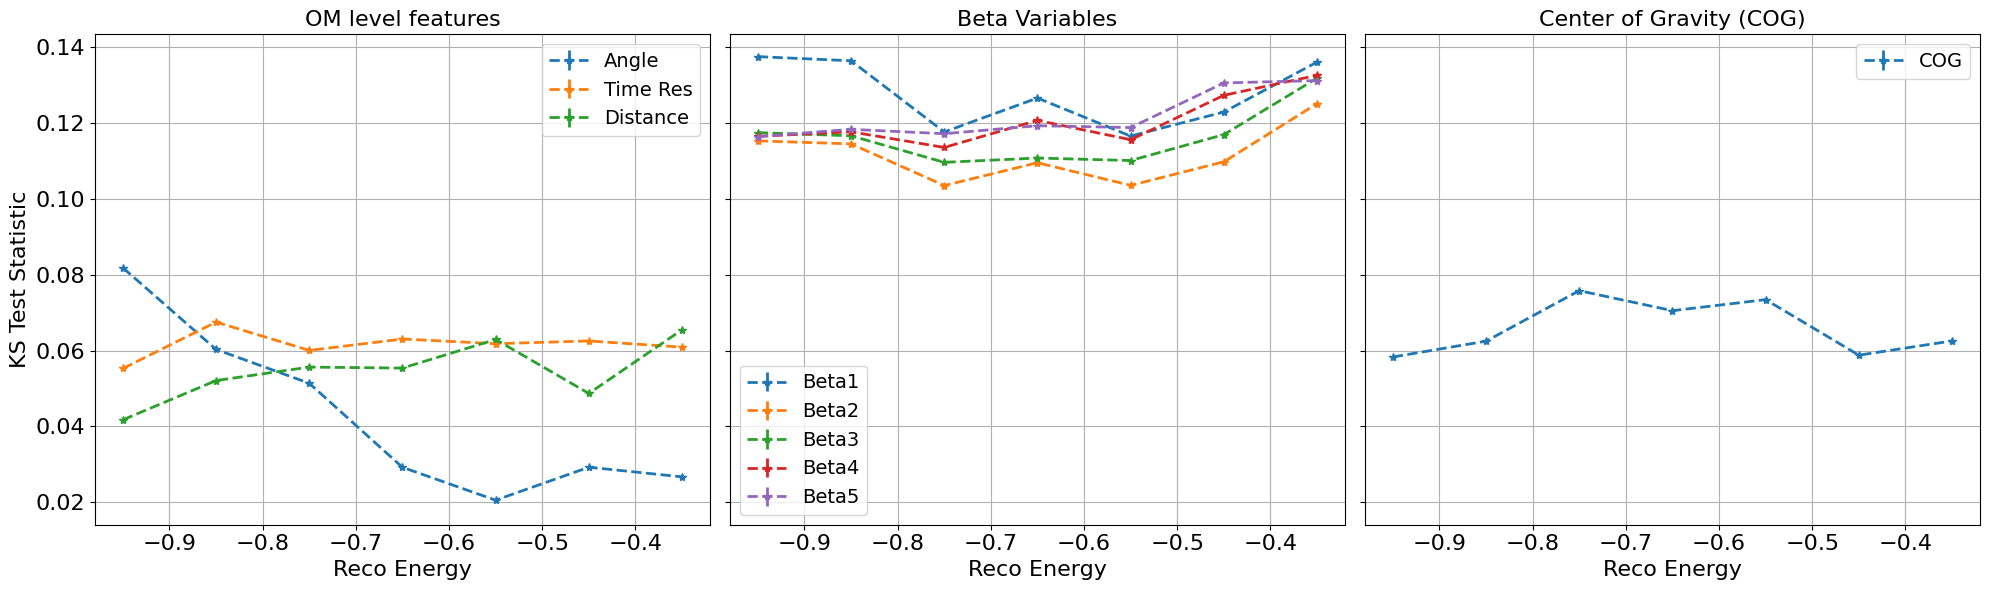

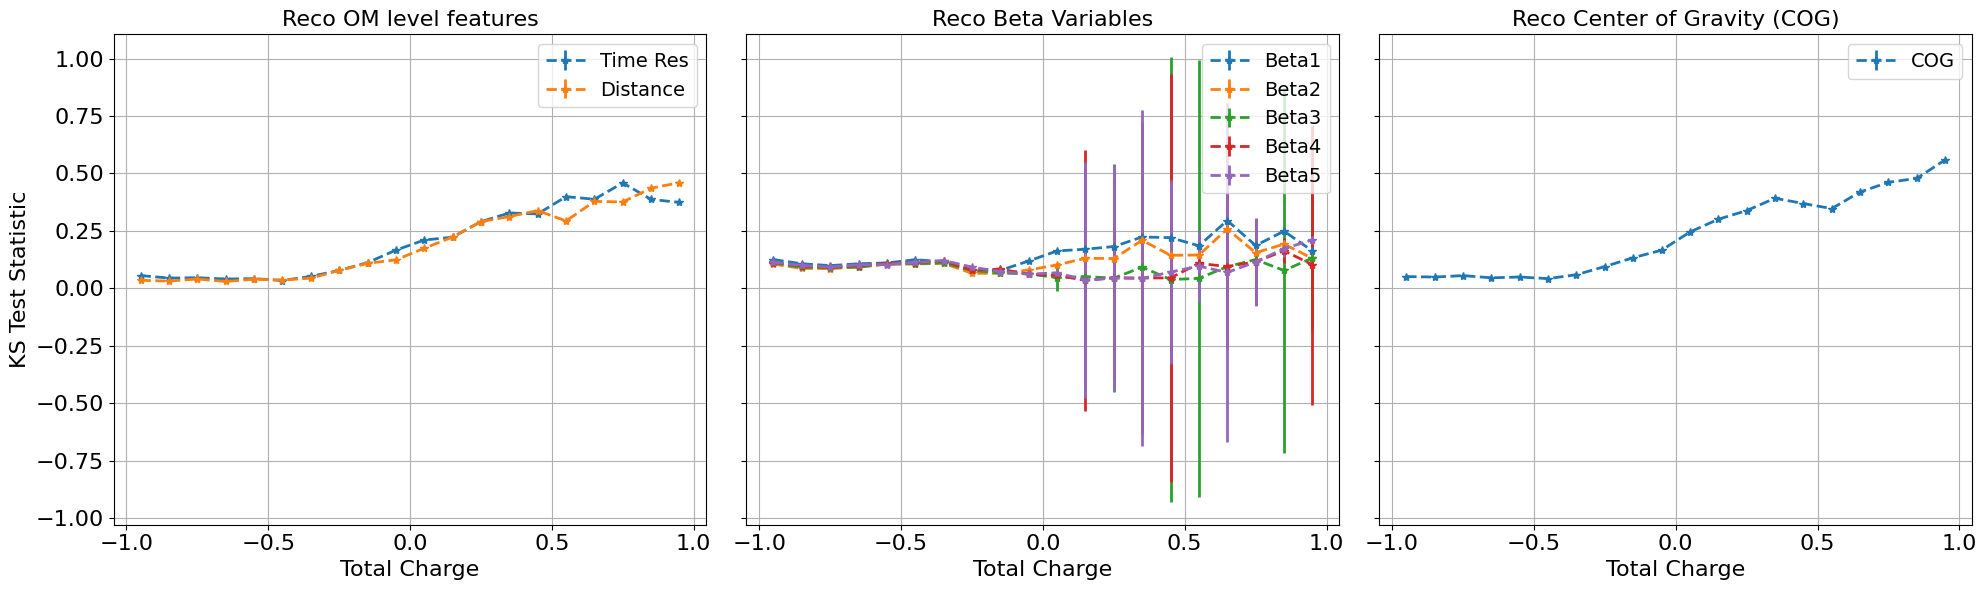

In [35]:
import matplotlib.pyplot as plt

# ---------------- Plot 2: Reco Energy ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].errorbar(bin_centers_median_angle, sep_var_median_angle, yerr=p_val_median_angle, fmt='*--', linewidth=2, label='Angle')
axs[0].errorbar(bin_centers_median_tres, sep_var_median_tres, yerr=p_val_median_tres, fmt='*--', linewidth=2, label='Time Res')
axs[0].errorbar(bin_centers_median_dist, sep_var_median_dist, yerr=p_val_median_tres, fmt='*--', linewidth=2, label='Distance')
axs[0].set_title('OM level features')
axs[0].set_xlabel('Reco Energy')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].errorbar(bin_centers_beta1_reco, sep_var_beta1_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta1')
axs[1].errorbar(bin_centers_beta2_reco, sep_var_beta2_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta2')
axs[1].errorbar(bin_centers_beta3_reco, sep_var_beta3_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta3')
axs[1].errorbar(bin_centers_beta4_reco, sep_var_beta4_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta4')
axs[1].errorbar(bin_centers_beta5_reco, sep_var_beta5_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta5')
axs[1].set_title('Beta Variables')
axs[1].set_xlabel('Reco Energy')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].errorbar(bin_centers_cog_reco, sep_var_cog_reco, yerr=p_val_cog_reco, fmt='*--', linewidth=2, label='COG')
axs[2].set_title('Center of Gravity (COG)')
axs[2].set_xlabel('Reco Energy')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ---------------- Plot 4: Total Charge (Reco) ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
#axs[0].errorbar(cbin_centers_median_angle, csep_var_median_angle, yerr=cp_val_median_angle, fmt='*--', linewidth=2, label='Angle')
axs[0].errorbar(cbin_centers_median_tres, csep_var_median_tres, yerr=cp_val_median_tres, fmt='*--', linewidth=2, label='Time Res')
axs[0].errorbar(cbin_centers_median_dist, csep_var_median_dist, yerr=cp_val_median_dist, fmt='*--', linewidth=2, label='Distance')
axs[0].set_title('Reco OM level features')
axs[0].set_xlabel('Total Charge')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].errorbar(cbin_centers_beta1_reco, csep_var_beta1_reco, yerr=cp_val_beta1_reco, fmt='*--', linewidth=2, label='Beta1')
axs[1].errorbar(cbin_centers_beta2_reco, csep_var_beta2_reco, yerr=cp_val_beta2_reco, fmt='*--', linewidth=2, label='Beta2')
axs[1].errorbar(cbin_centers_beta3_reco, csep_var_beta3_reco, yerr=cp_val_beta3_reco, fmt='*--', linewidth=2, label='Beta3')
axs[1].errorbar(cbin_centers_beta4_reco, csep_var_beta4_reco, yerr=cp_val_beta4_reco, fmt='*--', linewidth=2, label='Beta4')
axs[1].errorbar(cbin_centers_beta5_reco, csep_var_beta5_reco, yerr=cp_val_beta5_reco, fmt='*--', linewidth=2, label='Beta5')
axs[1].set_title('Reco Beta Variables')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].errorbar(cbin_centers_cog_reco, csep_var_cog_reco, yerr=cp_val_cog_reco, fmt='*--', linewidth=2, label='COG')
axs[2].set_title('Reco Center of Gravity (COG)')
axs[2].set_xlabel('Total Charge')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [26]:
np.arange(-1, 1, 0.1)

array([-1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -2.22044605e-16,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01])